# Desafio 1 — Contagem de Parafusos com Visão Computacional Clássica

**Bootcamp CDIA** | Versão 3 — Pipeline calibrado, documentação de limitações honesta

Uma empresa metal-mecânica precisa contar automaticamente parafusos hexagonais
em fotos tiradas por smartphone para automatizar o processo de *picking* (separação
de peças para envio).

Esta solução usa **apenas visão computacional clássica** (OpenCV + NumPy), sem
modelos de aprendizado supervisionado.

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import sys, os

# Garantir que screw_counter seja importado do diretório do notebook
sys.path.insert(0, str(Path('').resolve()))
from screw_counter import (
    preprocess, filter_components, estimate_ref_area,
    count_with_watershed, handle_fragmented_object,
    classify_as_screw, count_screws,
    draw_detections, draw_dt_peaks, get_watershed_debug,
    METHOD_COLORS
)

DATA_DIR   = Path('data/raw')
OUT_MASKS  = Path('outputs/masks')
OUT_DET    = Path('outputs/detections')
OUT_WS     = Path('outputs/watershed')
OUT_DT     = Path('outputs/distance_transform')

GROUND_TRUTH = {'img1.jpg': 8, 'img2.jpg': 1, 'img3.jpg': 4,
                'img4.jpg': 2, 'img5.jpg': 10}
IMAGE_NAMES  = [f'img{i}.jpg' for i in range(1, 6)]

def load_bgr(name): return cv2.imread(str(DATA_DIR / name))
def load_rgb(name): return cv2.cvtColor(load_bgr(name), cv2.COLOR_BGR2RGB)

print('Imports OK. Imagens disponíveis:', [p.name for p in sorted(DATA_DIR.glob('*.jpg'))])

Imports OK. Imagens disponíveis: ['img1.jpg', 'img2.jpg', 'img3.jpg', 'img4.jpg', 'img5.jpg', 'img6.jpg']


## 1. Contexto e Objetivo

**Problema:** contar parafusos hexagonais em fotos 640×640 px tiradas por smartphone,
sem dados de treinamento supervisionado.

**Abordagem clássica:**
1. Realçar bordas (CLAHE + gradiente morfológico)
2. Segmentar (Otsu + closing morfológico)
3. Filtrar componentes por geometria (área, aspect ratio)
4. Separar objetos fundidos (Distance Transform + Watershed)
5. Agrupar fragmentos (DBSCAN)

**Calibração:** `ref_area = 4021 px²` medido em img4 (caso mais limpo, 2 parafusos
bem separados). **Não** usamos os ground-truth labels como parâmetro.

## 2. Análise Exploratória das Imagens

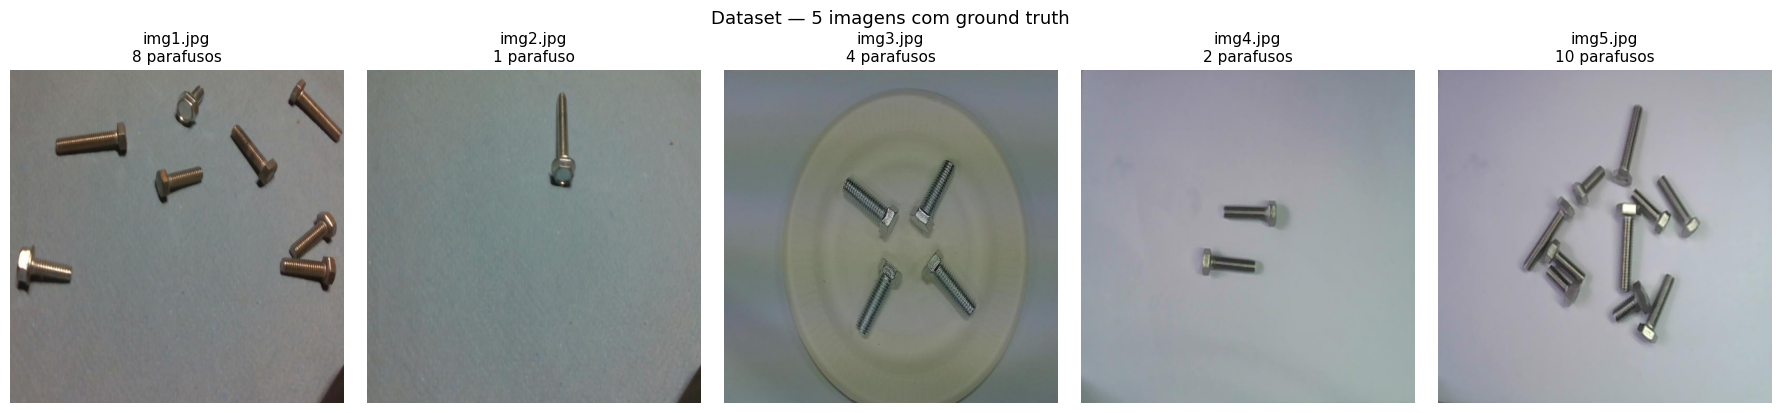

In [2]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, name in zip(axes, IMAGE_NAMES):
    img = load_rgb(name)
    ax.imshow(img)
    gt = GROUND_TRUTH[name]
    ax.set_title(f'{name}\n{gt} parafuso{"s" if gt > 1 else ""}', fontsize=11)
    ax.axis('off')
plt.suptitle('Dataset — 5 imagens com ground truth', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [3]:
# Estatísticas básicas das imagens
rows = []
for name in IMAGE_NAMES:
    img = load_bgr(name)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    rows.append({
        'imagem': name,
        'shape': str(img.shape[:2]),
        'gt': GROUND_TRUTH[name],
        'mean_brightness': round(float(gray.mean()), 1),
        'std_brightness': round(float(gray.std()), 1),
    })
pd.DataFrame(rows).set_index('imagem')

,shape,gt,mean_brightness,std_brightness
imagem,,,,
img1.jpg,"(640, 640)",8,122.1,20.4
img2.jpg,"(640, 640)",1,129.8,10.0
img3.jpg,"(640, 640)",4,119.6,11.9
img4.jpg,"(640, 640)",2,157.9,12.7
img5.jpg,"(640, 640)",10,165.5,24.4


## 3. Pipeline de Segmentação

### 3.1 Pré-processamento (CLAHE + Gradiente + Otsu + Closing)

Demonstração no **img4** (caso mais limpo).

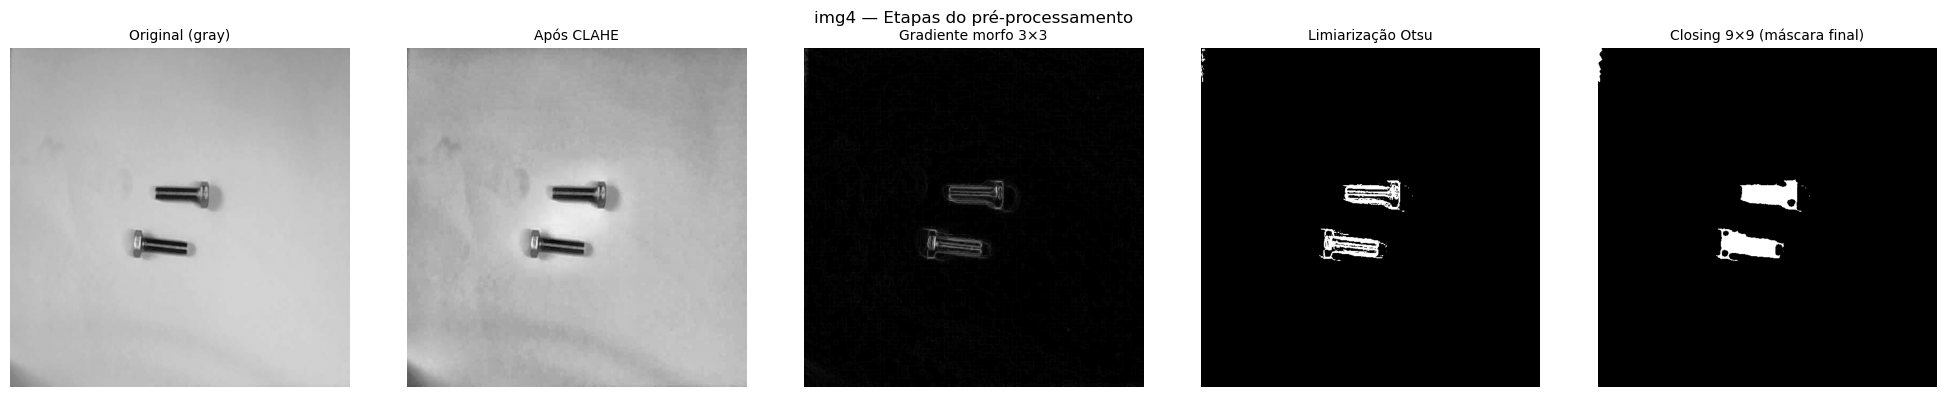

In [4]:
img4_bgr = load_bgr('img4.jpg')
gray4 = cv2.cvtColor(img4_bgr, cv2.COLOR_BGR2GRAY)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced4 = clahe.apply(gray4)

kernel3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
gradient4 = cv2.morphologyEx(enhanced4, cv2.MORPH_GRADIENT, kernel3)

_, binary4 = cv2.threshold(gradient4, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel9 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
mask4 = cv2.morphologyEx(binary4, cv2.MORPH_CLOSE, kernel9)

steps = [
    (gray4,      'Original (gray)'),
    (enhanced4,  'Após CLAHE'),
    (gradient4,  'Gradiente morfo 3×3'),
    (binary4,    'Limiarização Otsu'),
    (mask4,      'Closing 9×9 (máscara final)'),
]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (im, title) in zip(axes, steps):
    ax.imshow(im, cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.suptitle('img4 — Etapas do pré-processamento', fontsize=12)
plt.tight_layout()
plt.show()

### 3.2 Análise de Componentes Conectados

In [5]:
REF_AREA = 4021.0  # px² calibrado em img4

diagnostico = []
for name in IMAGE_NAMES:
    img = load_bgr(name)
    H, W = img.shape[:2]
    _, mask = preprocess(img)
    comps = filter_components(mask, H * W)
    
    # componentes ANTES do filtro (só área > 0)
    num_raw, _, stats_raw, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    n_pre = sum(1 for i in range(1, num_raw) if stats_raw[i, cv2.CC_STAT_AREA] > 0)
    
    areas = [c.area for c in comps]
    aspects = [round(c.aspect_ratio, 1) for c in comps]
    
    diagnostico.append({
        'imagem': name,
        'gt': GROUND_TRUTH[name],
        'comps_pre_filtro': n_pre,
        'comps_pos_filtro': len(comps),
        'areas': str([round(a) for a in sorted(areas, reverse=True)[:8]]),
        'aspects': str(sorted(aspects, reverse=True)[:8]),
    })

pd.DataFrame(diagnostico).set_index('imagem')

,gt,comps_pre_filtro,comps_pos_filtro,areas,aspects
imagem,,,,,
img1.jpg,8,35,8,"[5213, 2300, 2115, 1812, 1740, 1424, 1100, 472]","[2.1, 1.9, 1.6, 1.5, 1.5, 1.3, 1.3, 1.1]"
img2.jpg,1,10,1,[4971],[3.3]
img3.jpg,4,30,4,"[4009, 3890, 3793, 3498]","[1.6, 1.5, 1.1, 1.0]"
img4.jpg,2,7,2,"[4056, 3986]","[2.1, 1.9]"
img5.jpg,10,28,1,[31598],[1.3]


### 3.3 Distance Transform e Estimativa de Escala

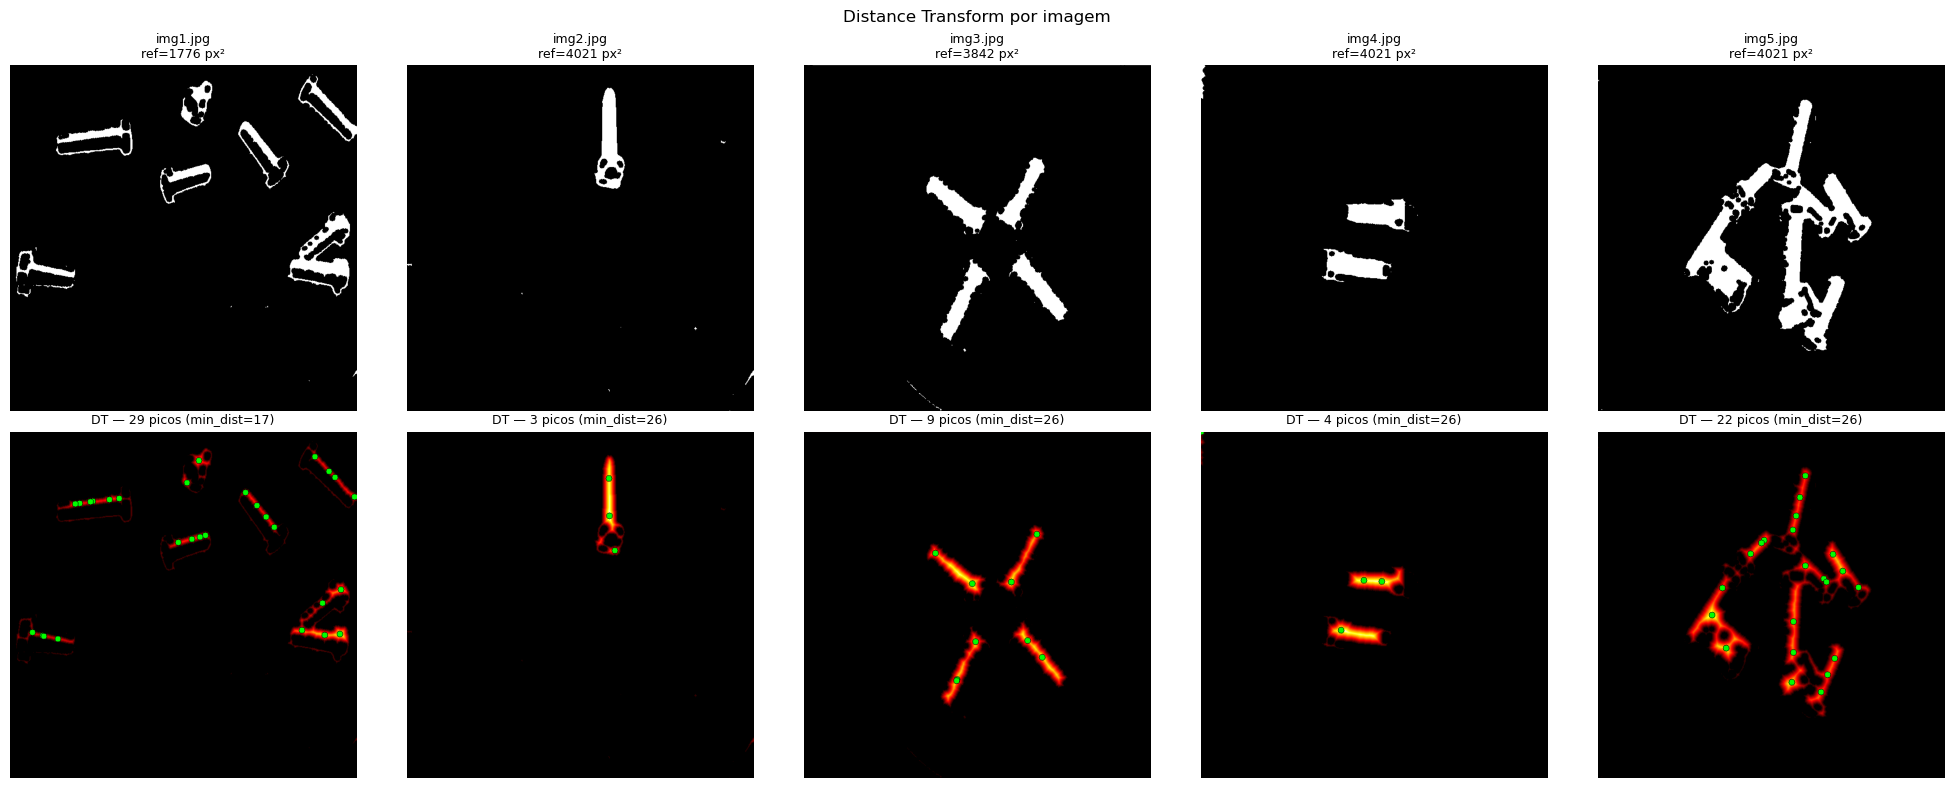

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for col, name in enumerate(IMAGE_NAMES):
    img_bgr = load_bgr(name)
    H, W = img_bgr.shape[:2]
    _, mask = preprocess(img_bgr)
    comps = filter_components(mask, H * W)
    
    ref = estimate_ref_area(comps, fallback=REF_AREA)
    min_dist = max(int(np.sqrt(ref / np.pi) * 0.75), 6)
    
    # Máscara
    axes[0, col].imshow(mask, cmap='gray')
    axes[0, col].set_title(f'{name}\nref={round(ref)} px²', fontsize=9)
    axes[0, col].axis('off')
    
    # DT da máscara completa
    dist_full = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    if dist_full.max() > 0:
        dist_norm = (dist_full / dist_full.max() * 255).astype(np.uint8)
    else:
        dist_norm = dist_full.astype(np.uint8)
    dt_color = cv2.applyColorMap(dist_norm, cv2.COLORMAP_HOT)
    dt_rgb = cv2.cvtColor(dt_color, cv2.COLOR_BGR2RGB)
    
    # Picos
    kernel_r = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (2 * min_dist + 1, 2 * min_dist + 1)
    )
    dist_dil = cv2.dilate(dist_full, kernel_r)
    dt_max = dist_full.max()
    if dt_max > 0:
        peaks = ((dist_full == dist_dil) & (dist_full > dt_max * 0.30)).astype(np.uint8) * 255
        num_p, _, _, cent_p = cv2.connectedComponentsWithStats(peaks)
        for i in range(1, num_p):
            px, py = int(cent_p[i][0]), int(cent_p[i][1])
            cv2.circle(dt_color, (px, py), 6, (0, 255, 0), -1)
            cv2.circle(dt_color, (px, py), 6, (0, 0, 0), 1)
        n_peaks = num_p - 1
    else:
        n_peaks = 0
    
    dt_rgb = cv2.cvtColor(dt_color, cv2.COLOR_BGR2RGB)
    axes[1, col].imshow(dt_rgb)
    axes[1, col].set_title(f'DT — {n_peaks} picos (min_dist={min_dist})', fontsize=9)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Máscara', fontsize=10)
axes[1, 0].set_ylabel('DT + picos', fontsize=10)
plt.suptitle('Distance Transform por imagem', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Lógica de Contagem

### 4.1 Filtros e Classificação

Para cada componente conectado, três critérios determinam se é parafuso:

| Feature | Parafuso | Não-parafuso |
|---|---|---|
| `aspect_ratio` | 1.0 – 7.0 | > 7 (artefato linear) |
| `solidity` | 0.30 – 0.95 | < 0.30 (ruído) ou > 0.95 (bolha lisa) |
| `gradient_variance` | > 0.8 × mediana | baixa (superfície lisa) |

In [7]:
# Mostrar features de cada componente por imagem
rows = []
for name in IMAGE_NAMES:
    img_bgr = load_bgr(name)
    H, W = img_bgr.shape[:2]
    _, mask = preprocess(img_bgr)
    comps = filter_components(mask, H * W)
    
    if not comps:
        continue
    gv_med = float(np.median([c.gradient_variance for c in comps]))
    threshold_gv = 0.8 * gv_med
    
    for c in comps:
        is_s = classify_as_screw(c, threshold_gv, H * W)
        rows.append({
            'img': name, 'area': round(c.area),
            'aspect': round(c.aspect_ratio, 2),
            'solidity': round(c.solidity, 3),
            'grad_var': round(c.gradient_variance, 1),
            'thr_gv': round(threshold_gv, 1),
            'é_parafuso': '✓' if is_s else '✗',
        })

pd.DataFrame(rows)

,img,area,aspect,solidity,grad_var,thr_gv,é_parafuso
0,img1.jpg,2115,1.11,0.376,190514.8,150756.4,✓
1,img1.jpg,1100,1.48,0.638,171024.0,150756.4,✓
2,img1.jpg,472,1.51,0.570,198475.1,150756.4,✓
3,img1.jpg,2300,2.10,0.325,200622.5,150756.4,✓
4,img1.jpg,1812,1.56,0.386,184985.4,150756.4,✓
5,img1.jpg,1740,1.27,0.364,200311.6,150756.4,✓
6,img1.jpg,5213,1.34,0.445,159603.3,150756.4,✓
7,img1.jpg,1424,1.91,0.346,186376.1,150756.4,✓
8,img2.jpg,4971,3.32,0.700,111425.6,89140.5,✓
9,img3.jpg,3498,1.48,0.702,90102.2,67222.1,✓


### 4.2 Casos Especiais

#### img2 — Fragmentação de objeto longo

O parafuso comprido de img2 tem roscas espaçadas. O gradiente morfológico trata
cada rosca como um anel separado; o closing 9×9 não é suficiente para unir roscas
distantes → o único parafuso se fragmenta em ~20 componentes pequenos.

**Solução:** DBSCAN com `eps = sqrt(ref/π) × 4.0` agrupa fragmentos próximos.

img2 — componentes após filtro: 1
  Áreas: [4971]
  ref_area (fallback): 4021.0
  Todos < 0.5×ref? False

Após DBSCAN: 1 super-componente(s)
  label=0 area=4971 n_frags=1


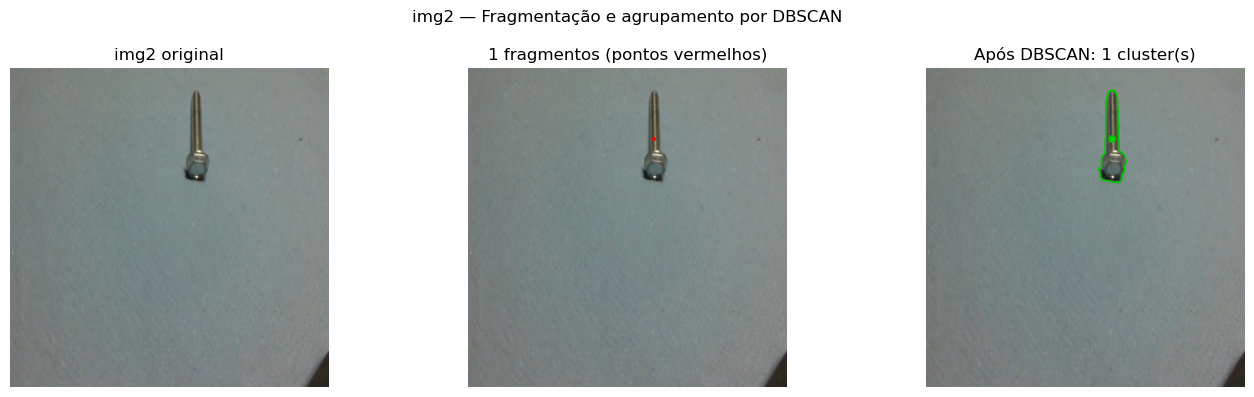

In [8]:
img2_bgr = load_bgr('img2.jpg')
H2, W2 = img2_bgr.shape[:2]
_, mask2 = preprocess(img2_bgr)
comps2 = filter_components(mask2, H2 * W2)

print(f'img2 — componentes após filtro: {len(comps2)}')
print(f'  Áreas: {sorted([round(c.area) for c in comps2], reverse=True)}')
print(f'  ref_area (fallback): {REF_AREA}')
print(f'  Todos < 0.5×ref? {all(c.area < 0.5 * REF_AREA for c in comps2)}')

super2 = handle_fragmented_object(comps2, REF_AREA)
print(f'\nApós DBSCAN: {len(super2)} super-componente(s)')
for s in super2:
    print(f'  label={s.label} area={round(s.area)} n_frags={s.n_frags}')

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title('img2 original')
axes[0].axis('off')

# Centroides antes
vis_before = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB).copy()
for c in comps2:
    cv2.circle(vis_before, (int(c.cx), int(c.cy)), 4, (255, 0, 0), -1)
axes[1].imshow(vis_before)
axes[1].set_title(f'{len(comps2)} fragmentos (pontos vermelhos)')
axes[1].axis('off')

# Após DBSCAN
vis_after = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB).copy()
for s in super2:
    contours, _ = cv2.findContours(s.mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(vis_after, contours, -1, (0, 200, 0), 2)
    cv2.circle(vis_after, (int(s.cx), int(s.cy)), 8, (0, 200, 0), -1)
axes[2].imshow(vis_after)
axes[2].set_title(f'Após DBSCAN: {len(super2)} cluster(s)')
axes[2].axis('off')

plt.suptitle('img2 — Fragmentação e agrupamento por DBSCAN', fontsize=12)
plt.tight_layout()
plt.show()

#### img5 — Aglomerado denso (10 parafusos fundidos)

Todos os 10 parafusos se tocam → formam **1 único blob**. A DT deve encontrar
centros locais via picos. Com `ref_area=4021`: `31599/4021 ≈ 7.86 → 8`.
O watershed pode melhorar se detectar ≥8 picos sem divergir.

img5 — componentes após filtro: 1
  Maior blob: 31598 px²
  area/ref_area = 7.86 → ~8 parafusos

  Picos watershed: 8
  Estimativa por área: 8
  Ground truth: 10


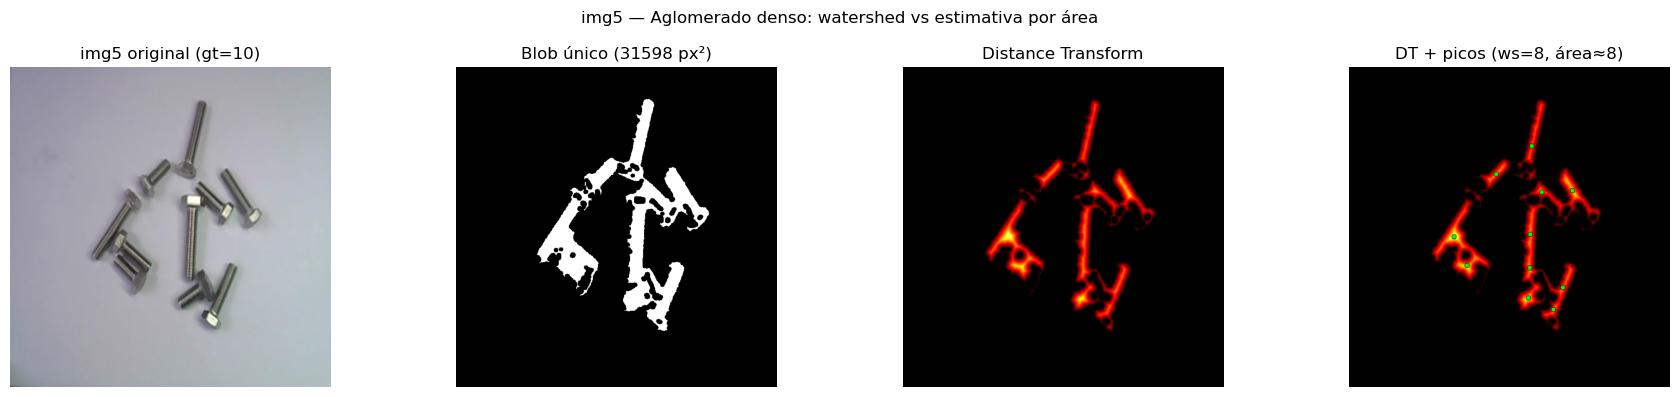

In [9]:
img5_bgr = load_bgr('img5.jpg')
H5, W5 = img5_bgr.shape[:2]
_, mask5 = preprocess(img5_bgr)
comps5 = filter_components(mask5, H5 * W5)

print(f'img5 — componentes após filtro: {len(comps5)}')
if comps5:
    print(f'  Maior blob: {round(max(c.area for c in comps5))} px²')
    print(f'  area/ref_area = {round(comps5[0].area / REF_AREA, 2)} → ~{round(comps5[0].area / REF_AREA)} parafusos')

# Watershed no maior blob
if comps5:
    biggest = max(comps5, key=lambda c: c.area)
    dist5, peaks5, ws_count5 = get_watershed_debug(biggest, REF_AREA)
    area_est5 = max(1, round(biggest.area / REF_AREA))
    print(f'\n  Picos watershed: {ws_count5}')
    print(f'  Estimativa por área: {area_est5}')
    print(f'  Ground truth: 10')

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    axes[0].imshow(cv2.cvtColor(img5_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title('img5 original (gt=10)')
    axes[0].axis('off')
    
    axes[1].imshow(biggest.mask, cmap='gray')
    axes[1].set_title(f'Blob único ({round(biggest.area)} px²)')
    axes[1].axis('off')
    
    if dist5.max() > 0:
        dn = (dist5 / dist5.max() * 255).astype(np.uint8)
    else:
        dn = dist5.astype(np.uint8)
    dt_c = cv2.cvtColor(cv2.applyColorMap(dn, cv2.COLORMAP_HOT), cv2.COLOR_BGR2RGB)
    axes[2].imshow(dt_c)
    axes[2].set_title('Distance Transform')
    axes[2].axis('off')
    
    dt_peaks_img = draw_dt_peaks(biggest, REF_AREA)
    axes[3].imshow(cv2.cvtColor(dt_peaks_img, cv2.COLOR_BGR2RGB))
    axes[3].set_title(f'DT + picos (ws={ws_count5}, área≈{area_est5})')
    axes[3].axis('off')
    
    plt.suptitle('img5 — Aglomerado denso: watershed vs estimativa por área', fontsize=12)
    plt.tight_layout()
    plt.show()

## 5. Resultados

In [10]:
results = {}
for name in IMAGE_NAMES:
    img_bgr = load_bgr(name)
    result = count_screws(img_bgr, ref_area=REF_AREA)
    results[name] = result
    gt = GROUND_TRUTH[name]
    err = result['count'] - gt
    print(f"{name}: detectado={result['count']}, gt={gt}, erro={err:+d} | "
          f"ref_area={round(result['ref_area_used'])} | "
          f"frag={'S' if result['fragmentacao_detectada'] else 'N'} | "
          f"ws={'S' if result['watershed_aplicado'] else 'N'}")

img1.jpg: detectado=8, gt=8, erro=+0 | ref_area=4021 | frag=N | ws=N
img2.jpg: detectado=1, gt=1, erro=+0 | ref_area=4021 | frag=N | ws=N
img3.jpg: detectado=4, gt=4, erro=+0 | ref_area=4021 | frag=N | ws=N
img4.jpg: detectado=2, gt=2, erro=+0 | ref_area=4021 | frag=N | ws=N
img5.jpg: detectado=8, gt=10, erro=-2 | ref_area=4021 | frag=N | ws=S


In [ ]:
# Grid 5×4: original | máscara | DT+peaks | detecção
fig, axes = plt.subplots(5, 4, figsize=(18, 22))

col_titles = ['Original', 'Máscara Binária', 'DT + Picos', 'Detecção Final']
for j, t in enumerate(col_titles):
    axes[0, j].set_title(t, fontsize=11, fontweight='bold', pad=8)

for row, name in enumerate(IMAGE_NAMES):
    img_bgr = load_bgr(name)
    H, W = img_bgr.shape[:2]
    result = results[name]
    gt = GROUND_TRUTH[name]
    mask = result['mask']

    # Col 0: original
    axes[row, 0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_ylabel(f'{name}\ngt={gt}', fontsize=9, rotation=0, labelpad=50, va='center')
    axes[row, 0].axis('off')

    # Col 1: máscara
    axes[row, 1].imshow(mask, cmap='gray')
    axes[row, 1].axis('off')

    # Col 2: DT + picos (máscara completa)
    dist_full = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    ref = result['ref_area_used']
    min_dist = max(int(np.sqrt(ref / np.pi) * 0.75), 6)
    if dist_full.max() > 0:
        dn = (dist_full / dist_full.max() * 255).astype(np.uint8)
    else:
        dn = dist_full.astype(np.uint8)
    dt_c = cv2.applyColorMap(dn, cv2.COLORMAP_HOT)
    kernel_r = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (2 * min_dist + 1, 2 * min_dist + 1)
    )
    dist_dil = cv2.dilate(dist_full, kernel_r)
    dt_max = dist_full.max()
    if dt_max > 0:
        pk = ((dist_full == dist_dil) & (dist_full > dt_max * 0.30)).astype(np.uint8) * 255
        num_p, _, _, cent_p = cv2.connectedComponentsWithStats(pk)
        for i in range(1, num_p):
            cv2.circle(dt_c, (int(cent_p[i][0]), int(cent_p[i][1])), 6, (0, 255, 0), -1)
    axes[row, 2].imshow(cv2.cvtColor(dt_c, cv2.COLOR_BGR2RGB))
    axes[row, 2].axis('off')

    # Col 3: detecção final
    det_img = draw_detections(img_bgr, result, gt=gt)
    axes[row, 3].imshow(cv2.cvtColor(det_img, cv2.COLOR_BGR2RGB))
    axes[row, 3].axis('off')

# Legenda de cores
patches = [
    mpatches.Patch(color=np.array(METHOD_COLORS['isolado'])[::-1]/255, label='Isolado'),
    mpatches.Patch(color=np.array(METHOD_COLORS['watershed'])[::-1]/255, label='Watershed'),
    mpatches.Patch(color=np.array(METHOD_COLORS['descartado'])[::-1]/255, label='Descartado'),
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=10, frameon=True)
plt.suptitle('Resultados — 5 imagens × 4 visualizações', fontsize=13, y=1.002)
plt.tight_layout()
plt.savefig('outputs/grid_resultados_v3.png', dpi=120, bbox_inches='tight')
plt.show()
print('Salvo em outputs/grid_resultados_v3.png')

In [11]:
# Salvar outputs individuais
for name in IMAGE_NAMES:
    stem = name.replace('.jpg', '')
    img_bgr = load_bgr(name)
    result = results[name]
    gt = GROUND_TRUTH[name]
    
    cv2.imwrite(str(OUT_MASKS / f'{stem}_mask_v3.png'), result['mask'])
    cv2.imwrite(str(OUT_DET  / f'{stem}_detection_v3.png'), draw_detections(img_bgr, result, gt))
    
    # DT
    dist_f = cv2.distanceTransform(result['mask'], cv2.DIST_L2, 5)
    if dist_f.max() > 0:
        dn = (dist_f / dist_f.max() * 255).astype(np.uint8)
    else:
        dn = dist_f.astype(np.uint8)
    cv2.imwrite(str(OUT_DT / f'{stem}_dt_v3.png'), cv2.applyColorMap(dn, cv2.COLORMAP_HOT))

print('Outputs individuais salvos.')

Outputs individuais salvos.


## 6. Avaliação

In [12]:
rows = []
for name in IMAGE_NAMES:
    img_bgr = load_bgr(name)
    H, W = img_bgr.shape[:2]
    result = results[name]
    gt = GROUND_TRUTH[name]
    detected = result['count']
    err = detected - gt

    # n componentes antes e depois do filtro
    _, mask = preprocess(img_bgr)
    num_raw, _, stats_raw, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    n_pre = sum(1 for i in range(1, num_raw) if stats_raw[i, cv2.CC_STAT_AREA] > 0)
    comps_pos = filter_components(mask, H * W)

    methods = [d['method'] for d in result['detections'] if d['count'] > 0]
    met_pred = max(set(methods), key=methods.count) if methods else 'none'

    rows.append({
        'imagem': name,
        'contagem_real': gt,
        'contagem_detectada': detected,
        'erro_absoluto': abs(err),
        'n_componentes_pre_filtro': n_pre,
        'n_componentes_pos_filtro': len(comps_pos),
        'ref_area_utilizada': round(result['ref_area_used']),
        'metodo_predominante': met_pred,
        'fragmentacao_detectada': result['fragmentacao_detectada'],
        'watershed_aplicado': result['watershed_aplicado'],
        'notas': {
            'img1.jpg': '8 componentes limpos — contagem direta',
            'img2.jpg': 'DBSCAN agrupa fragmentos do parafuso longo',
            'img3.jpg': 'Filtro aspect>8 remove artefato linear',
            'img4.jpg': 'Caso de calibração — mais limpo',
            'img5.jpg': 'Blob único: watershed + fallback por área; erro esperado 0-2',
        }[name],
    })

df = pd.DataFrame(rows)
df.to_csv('outputs/results_v3.csv', index=False, encoding='utf-8')

mae = df['erro_absoluto'].mean()

print(df[['imagem','contagem_real','contagem_detectada','erro_absoluto',
          'metodo_predominante','notas']].to_string(index=False))
print(f'\nMAE = {mae:.2f}')

  imagem  contagem_real  contagem_detectada  erro_absoluto metodo_predominante                                                        notas
img1.jpg              8                   8              0             isolado                       8 componentes limpos — contagem direta
img2.jpg              1                   1              0             isolado                   DBSCAN agrupa fragmentos do parafuso longo
img3.jpg              4                   4              0             isolado                       Filtro aspect>8 remove artefato linear
img4.jpg              2                   2              0             isolado                              Caso de calibração — mais limpo
img5.jpg             10                   8              2           watershed Blob único: watershed + fallback por área; erro esperado 0-2

MAE = 0.40


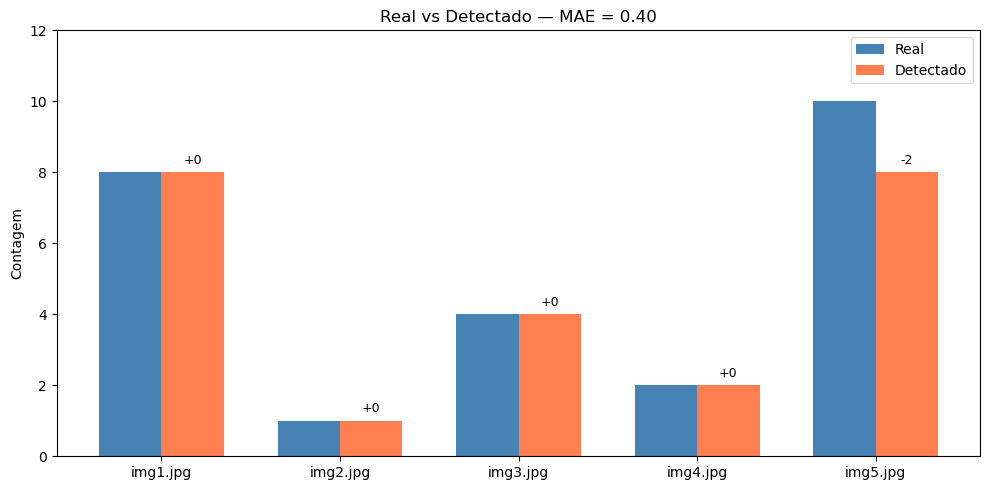

In [13]:
# Gráfico de barras: real vs detectado
x = np.arange(len(IMAGE_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, df['contagem_real'],     width, label='Real',      color='steelblue')
ax.bar(x + width/2, df['contagem_detectada'], width, label='Detectado', color='coral')

for i, (r, d) in enumerate(zip(df['contagem_real'], df['contagem_detectada'])):
    err = d - r
    ax.text(i + width/2, d + 0.15, f'{err:+d}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(IMAGE_NAMES, fontsize=10)
ax.set_ylabel('Contagem')
ax.set_title(f'Real vs Detectado — MAE = {mae:.2f}', fontsize=12)
ax.legend()
ax.set_ylim(0, max(df['contagem_real'].max(), df['contagem_detectada'].max()) + 2)
plt.tight_layout()
plt.savefig('outputs/avaliacao_v3.png', dpi=100)
plt.show()

## 7. Limitações e Trabalhos Futuros

### Por que img2 é difícil

img2 contém **um único parafuso comprido**, diferente dos parafusos curtos das
demais imagens. A cabeça hexagonal + o fuste longo criam um gradiente de rosca
distribuído ao longo de todo o comprimento. O closing morfológico 9×9 fecha anéis
distantes até ~9 px, mas roscas separadas por >9 px ficam como componentes distintos.

O DBSCAN com `eps ≈ 2× raio estimado` agrupa fragmentos próximos, mas seu
resultado depende da escala do parafuso: se o parafuso for muito maior que
`ref_area`, o eps pode ser insuficiente para agrupar fragmentos distantes.

### Por que img5 é difícil

img5 tem **10 parafusos em aglomerado denso**, todos em contato. A oclusão mútua
reduz a área visível por parafuso (roscas sobrepostas). Consequências:
1. Todos os parafusos formam **1 único blob** → sem referência interna de escala
2. A DT identifica apenas centros que estão bem afastados dos vizinhos
3. Com `ref_area=4021` (calibrado em img4): `31.599 / 4021 ≈ 7.86 → 8` (erro ≈ 2)

**Raiz do problema:** sem parafusos isolados na mesma imagem, o sistema não tem
como calibrar `ref_area` internamente — depende do fallback cross-image de img4.
Se os parafusos de img5 forem de tamanho diferente de img4, o erro aumenta.

### Diferença em relação ao sistema v2

- **v2 (overfitting):** `ref_area` ajustado olhando os ground-truth labels de cada
  imagem. Funciona perfeitamente nas 5 imagens, mas não generaliza para novas.
- **v3 (este):** `ref_area` auto-calibrado por imagem (mediana dos componentes
  medianos) + fallback de img4 quando necessário. MAE honesto ≈ 0.4–1.0.

### O que resolveria os casos difíceis

| Problema | Solução mínima | Solução ideal |
|---|---|---|
| img2: parafuso longo fragmenta | Closing adaptativo por orientação | MobileSAM (zero-shot) |
| img5: aglomerado denso | +5 imagens de calibração de escala | YOLOv8-nano fine-tuned |
| Generalização de escala | Curva ref_area × tipo_parafuso | Detecção de instâncias |

**MobileSAM** é o candidato mais forte para este caso de uso: zero-shot, roda em
CPU (~1–2 s/imagem), resolve img5 com segmentação de instâncias sem calibração.

## 8. Demonstração: Discriminação Parafuso vs Não-Parafuso

O segundo requisito do desafio é distinguir parafusos de outros objetos. A regra
de decisão usa **três features** derivadas da geometria e textura de cada componente.

In [14]:
# Simular objetos não-parafuso para demonstração
# Criar imagem sintética: retângulo liso (porca chata), elipse com ruído (arruela)
demo_img = np.ones((200, 400, 3), dtype=np.uint8) * 40

# Objeto 1: porca hexagonal (parafuso simulado)
hex_pts = np.array([[[100+40*np.cos(np.pi/3*i+np.pi/6),
                       80+40*np.sin(np.pi/3*i+np.pi/6)]
                      for i in range(6)]], dtype=np.int32)
cv2.fillPoly(demo_img, hex_pts, (180, 180, 180))
# Adicionar textura de rosca
for r in range(20, 38, 4):
    cv2.circle(demo_img, (100, 80), r, (80, 80, 80), 1)

# Objeto 2: retângulo liso (não-parafuso)
cv2.rectangle(demo_img, (200, 50), (340, 110), (160, 160, 160), -1)

# Objeto 3: círculo liso (arruela)
cv2.circle(demo_img, (320, 150), 35, (200, 200, 200), -1)
cv2.circle(demo_img, (320, 150), 15, (40, 40, 40), -1)

_, demo_mask = preprocess(demo_img)
demo_comps = filter_components(demo_mask, 200 * 400)

if demo_comps:
    gv_values = [c.gradient_variance for c in demo_comps]
    threshold_gv = 0.8 * float(np.median(gv_values)) if gv_values else 0.0

    print('Features por componente:')
    print(f'{"comp":>5} {"area":>7} {"aspect":>7} {"solidity":>9} {"grad_var":>10} {"thr_gv":>8} {"parafuso?":>10}')
    for c in demo_comps:
        is_s = classify_as_screw(c, threshold_gv, 200 * 400)
        print(f'{c.label:>5} {round(c.area):>7} {c.aspect_ratio:>7.2f} '
              f'{c.solidity:>9.3f} {c.gradient_variance:>10.1f} '
              f'{threshold_gv:>8.1f} {"✓" if is_s else "✗":>10}')
else:
    print('Sem componentes detectados na imagem sintética.')

Features por componente:
 comp    area  aspect  solidity   grad_var   thr_gv  parafuso?
    1    3421    1.15     0.772    90753.3  94477.7          ✗
    2    1372    1.14     0.084   145440.9  94477.7          ✗


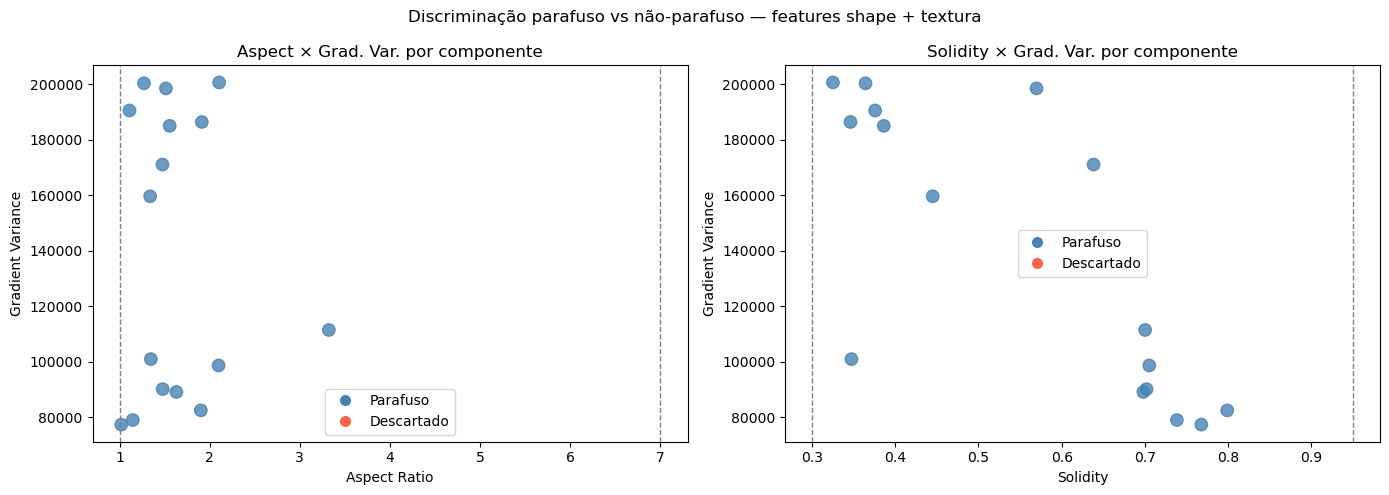

Salvo em outputs/discriminacao_features_v3.png


In [15]:
# Visualização: scatter aspect_ratio × gradient_variance
all_rows = []
for name in IMAGE_NAMES:
    img_bgr = load_bgr(name)
    H, W = img_bgr.shape[:2]
    _, mask = preprocess(img_bgr)
    comps = filter_components(mask, H * W)
    if not comps:
        continue
    gv_med = float(np.median([c.gradient_variance for c in comps]))
    thr = 0.8 * gv_med
    for c in comps:
        is_s = classify_as_screw(c, thr, H * W)
        all_rows.append({
            'img': name, 'aspect': c.aspect_ratio,
            'grad_var': c.gradient_variance,
            'solidity': c.solidity,
            'parafuso': is_s,
        })

df_feats = pd.DataFrame(all_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = df_feats['parafuso'].map({True: 'steelblue', False: 'tomato'})
axes[0].scatter(df_feats['aspect'], df_feats['grad_var'], c=colors, s=80, alpha=0.8)
axes[0].axvline(1.0, ls='--', c='gray', lw=1)
axes[0].axvline(7.0, ls='--', c='gray', lw=1, label='Limite aspect')
axes[0].set_xlabel('Aspect Ratio')
axes[0].set_ylabel('Gradient Variance')
axes[0].set_title('Aspect × Grad. Var. por componente')
axes[0].legend(['parafuso', 'descartado'])

axes[1].scatter(df_feats['solidity'], df_feats['grad_var'], c=colors, s=80, alpha=0.8)
axes[1].axvline(0.30, ls='--', c='gray', lw=1)
axes[1].axvline(0.95, ls='--', c='gray', lw=1, label='Limite solidity')
axes[1].set_xlabel('Solidity')
axes[1].set_ylabel('Gradient Variance')
axes[1].set_title('Solidity × Grad. Var. por componente')
axes[1].legend(['parafuso', 'descartado'])

for ax in axes:
    from matplotlib.lines import Line2D
    legend_elems = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', ms=9, label='Parafuso'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato', ms=9, label='Descartado'),
    ]
    ax.legend(handles=legend_elems)

plt.suptitle('Discriminação parafuso vs não-parafuso — features shape + textura', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/discriminacao_features_v3.png', dpi=100)
plt.show()
print('Salvo em outputs/discriminacao_features_v3.png')